### Necessary Imports

In [1]:
from astropy.table import Table
from common_functions import reduce, read_sim_path, inject_flux
import glob
import lightkurve as lk
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import os
import pathlib
from pyasassn.client import SkyPatrolClient

#### Now we'll use the stored rcparams.txt file to format our figure

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

#### Now we'll open the ASAS-SN client to grab our template, and I'll make a functon to do it. 

You can swap the star out with any you would like to test how injection looks

In [3]:
client = SkyPatrolClient()

Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.20 (11 SEPTEMBER 2025)
Please upgrade your client if not up to date.

We are reprocessing a number of lightcurves in database.
Once finished we should have more complete and higher quality photometry.
Thank you for your patience,
K. Hart (22 MAY 2025)




In [4]:
def pipeline(objid):
    """ Download a light curve off the ASAS-SN servers

    Args:
        objid (int): an ASAS-SN permanent identifier
        minimum (pyasassn.LightCurve): a noise template.LightCurve object to inject simulation flux into

    Returns:
        saved_lc_fin (pyasassn.LightCurve): the reduced light curve as a pyasassn.LightCurve object
        
    """
    lcs = client.query_list([objid], download=True)
    for lc in lcs.itercurves():
        savedlc = lc
    savedlc_fin = reduce(savedlc)
    return savedlc_fin

lcsave = pipeline(463856975202)

Pulled 1 of 1


#### This bit here will read in our simulation

In [5]:
simulation_file = glob.glob("files/sim900184.fits")
simulation = read_sim_path(simulation_file[0])
newflux = inject_flux(simulation, lcsave)

#### Now we'll plot it

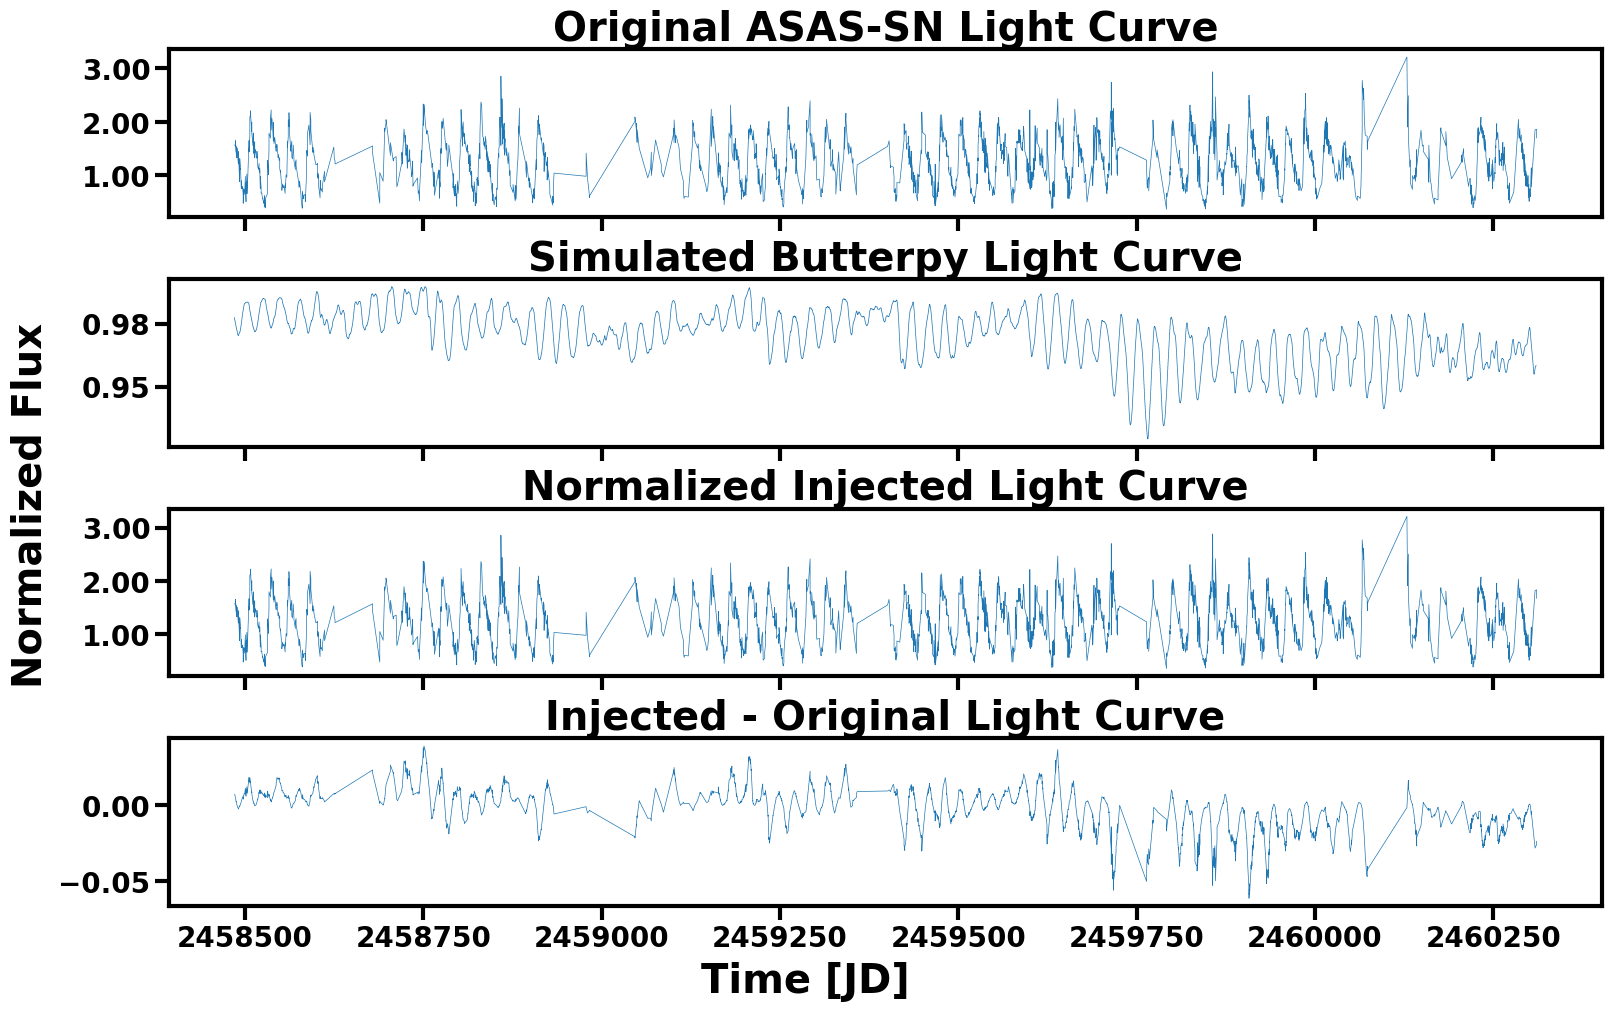

In [6]:
formatter1 = ticker.FormatStrFormatter('%.2f') # Format of the y-axis axis ticks
formatter2 = ticker.FormatStrFormatter('%.f') # Format of the x-axis axis ticks

fig, [ax1, ax2, ax3, ax4] = plt.subplots(figsize=(16, 10), ncols = 1, nrows = 4, sharex=True, layout='constrained')
fig.supylabel('Normalized Flux', weight='bold')
fig.supxlabel('Time [JD]', weight='bold')
axes = [ax1, ax2, ax3, ax4]

noiseylc = lk.LightCurve(time=lcsave.jd, flux=lcsave.flux)
sim_lc = lk.LightCurve(time=simulation.time, flux=simulation.flux)
injected = lk.LightCurve(time=lcsave.jd, flux=newflux)
subtracted = lk.LightCurve(time=lcsave.jd, flux=(newflux-lcsave.flux))

lightcurves = [noiseylc, sim_lc, injected, subtracted]
names = ["Original ASAS-SN Light Curve", "Simulated Butterpy Light Curve", "Normalized Injected Light Curve", "Injected - Original Light Curve"]

[lightcurve.plot(ax=axnum, xlabel='', ylabel='', rasterized=True) for (lightcurve, axnum) in zip(lightcurves, axes)]
[axnum.set_title(name, weight='bold') for name, axnum in zip(names, axes)]
[axnum.yaxis.set_major_formatter(formatter1) for axnum in axes[:3]]

plt.locator_params(axis='x', nbins=10)
ax4.xaxis.set_major_formatter(formatter2)

#plt.savefig('lc+inject.pdf')